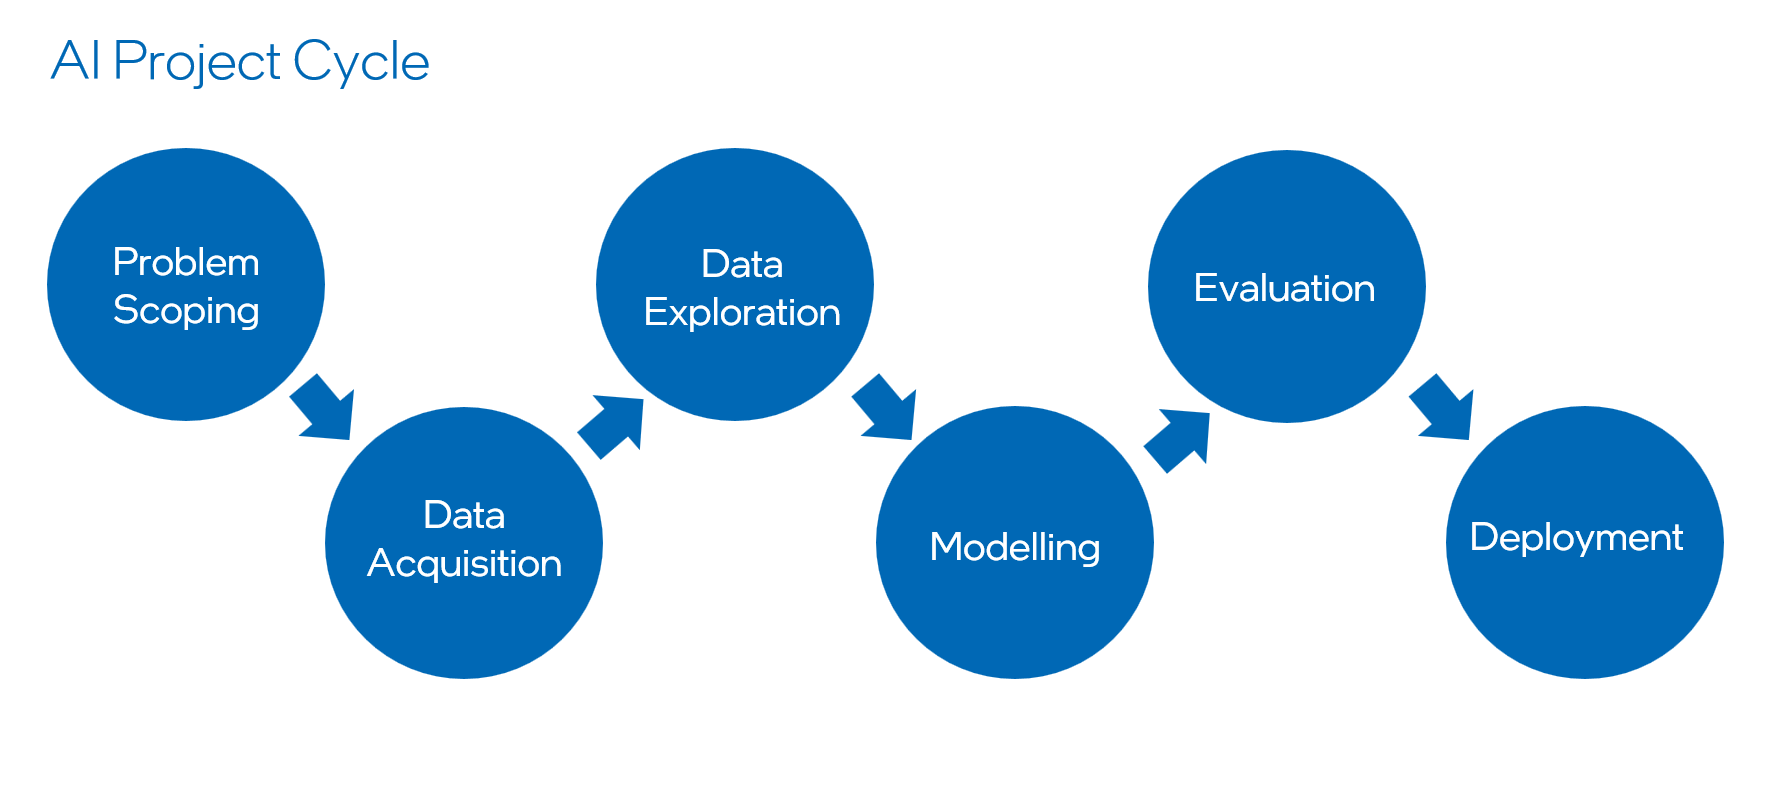

## Problem Scoping - Understanding the Problem Statement (AI Project Cycle - Step 1)

 <font size="+1">**Sentiment Analysis of Social Media Posts** </font>

여기 소셜 미디어 게시물에 대한 감정 분석은 Twitter, Facebook, Instagram 등의 소셜 미디어 플랫폼에서 텍스트 데이터를 분석하는 알고리즘과 기계 학습 기술을 사용하여 사용자가 게시하는 메시지가 전달하는 전반적인 감정적 톤이나 태도를 결정합니다. 이는 긍정적/부정적 감정, 행복 수준, 표현된 분노나 두려움, 슬픔 등을 포함할 수 있습니다. 이러한 분석 결과는 다양한 주제에 대한 대중의 의견을 파악하고, 브랜드 명성을 추적하며, 신흥 추세를 모니터링하고, 주요 문제가 되기 전에 잠재적 위기를 식별하는 데 비즈니스, 마케터, 연구자 및 정부 기관에서 자주 사용됩니다.

이 노트북에서는 인종 차별과 사회적 불의에 관한 트윗에 주목할 것입니다.

인터넷 혐오는 매우 흔하고 빈번합니다. Facebook과 Twitter는 자유로운 표현과 부적절한 자료를 찾아내고 검열하는 것 사이의 균형을 맞춰야 합니다. 혐오 발언이 혐오 범죄로 이어지기 때문에 이를 감지하고 조절하는 것이 중요합니다. 혐오 발언을 조장하는 사람들을 조기에 식별하는 것은 발언에서 행동으로의 전환을 막는 데 도움이 될 수 있는 노력을 지원할 수 있습니다. Twitter와 Facebook은 혐오 발언과 싸우고 있습니다. 이러한 이유에도 불구하고, 혐오 발언에 대한 자연어 처리 연구는 일반적인 정의, 인구 통계적 영향 및 가장 유용한 특징을 필요로 하기 때문에 매우 제한적이었습니다.

## Dataset:  Data Acquisition (AI Project Cycle - Step 2)
Source - https://www.kaggle.com/datasets/dv1453/twitter-sentiment-analysis-analytics-vidya

이 데이터셋은 감정 분석을 사용하여 혐오 발언을 식별하는 단계로 하나의 해커톤에서 사용되었습니다

### Import the useful Packages and Libraries

In [2]:
import re 
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
#import string 
import nltk 
import warnings 
#from timeit import default_timer as timer 

warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

In [1]:
!pip install wordcloud

In [3]:
from wordcloud import WordCloud,ImageColorGenerator 
from PIL import Image 
#import urllib 
import requests 

In [4]:
from sklearn import metrics 
from sklearn.model_selection import train_test_split 

### Load/Read the Dataset

In [4]:
train = pd.read_csv('train.csv')

train_original=train.copy()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [5]:
test = pd.read_csv('test.csv')

test_original=test.copy()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17197 entries, 0 to 17196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      17197 non-null  int64 
 1   tweet   17197 non-null  object
dtypes: int64(1), object(1)
memory usage: 268.8+ KB


merge = train.append(test, ignore_index=True, sort=True) 코드는 두 개의 데이터프레임 train과 test를 하나로 합치는 역할을 합니다. 각 매개변수의 의미는 다음과 같습니다:

train과 test: 합칠 두 개의 데이터프레임입니다. train은 훈련 데이터, test는 테스트 데이터를 나타냅니다.

ignore_index=True: 새롭게 생성된 데이터프레임에서 인덱스를 무시하고, 기존 인덱스를 새롭게 부여합니다. 즉, 합쳐진 데이터프레임의 인덱스가 0부터 시작하게 됩니다.

sort=True: 합치는 과정에서 열의 순서를 알파벳 순으로 정렬합니다. 이는 열의 순서가 중요하지 않은 경우에 사용됩니다. 기본값은 False로, 이를 설정하면 합칠 때 열의 순서가 유지됩니다. 즉 내용과는 상관없고 Column순서만 정렬 

따라서, 이 코드는 train과 test 데이터프레임을 행 단위로 합쳐서 새로운 데이터프레임 merge를 생성합니다. 새로운 데이터프레임은 인덱스가 0부터 시작하며, 열은 알파벳 순으로 정렬됩니다.

In [6]:
#Combining the two for text pre-processing
merge = train._append(test, ignore_index=True, sort=True)  

In [7]:
print(f'Train Len : {len(train)}, Test Len : {len(test)}, Merge Len : {len(merge)}') 

Train Len : 31962, Test Len : 17197, Merge Len : 49159


### View the data

In [9]:
# head()를 이용해서 처음 5개 행을 보여주세요
# your code here 
merge.head()

,id,label,tweet
0,1,0.0,@user when a father is dysfunctional and is s...
1,2,0.0,@user @user thanks for #lyft credit i can't us...
2,3,0.0,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation


In [10]:
# tail()을 이용해서 마지막 5개 행을 보여주세요 
# test 자료에는 label이 없기 때문에 NaN으로 값이 들어갑니다.
# your code here 
merge.tail()

,id,label,tweet
49154,49155,NaN,thought factory: left-right polarisation! #tru...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...
49157,49158,NaN,"happy, at work conference: right mindset leads..."
49158,49159,NaN,"my song ""so glad"" free download! #shoegaze ..."


### Attribute Information-


훈련 데이터셋은 테스트 데이터셋과 달리 레이블 필드를 포함하고 있습니다. 여기에서 레이블 '1'은 트윗이 편견이 있거나 편향되었음을 나타내고, 레이블 '0'은 트윗이 편견이 없음을 나타냅니다. 우리의 목표는 주어진 테스트 데이터셋에 레이블을 예측하는 것입니다.

id : 제공된 데이터셋의 각 트윗에 할당된 ID입니다.

tweets : 여러 출처에서 긍정적 또는 부정적 감정을 가진 트윗 모음입니다.

label : 감정 레이블 '0'을 가진 트윗은 긍정적이고, 감정 레이블 '1'을 가진 트윗은 부정적입니다. 0은 긍정 / 1은 부정입니다

## Data Preprocessing ------ Data Exploration(AI Project Cycle - Step 3)

탐색적 데이터 분석(EDA : Exploratory Data Analysis)의 목표는 데이터셋에 대한 통찰력을 극대화하고 데이터셋의 기본 구조를 이해하는 것입니다.

EDA는 아래에 언급된 단계들을 포함할 수 있습니다:

- 탐색: 데이터 정보를 확인합니다.
- 데이터의 행과 열 수 확인: 데이터가 얼마나 많은 행과 열로 구성되어 있는지 확인합니다.
- 누락된 값/결측값 찾기: 데이터에서 누락된 값이나 결측값을 찾습니다.
- 누락된 값 채우기: fillna (평균, 중앙값 또는 최빈값을 사용)를 사용합니다.
- 시각화: 데이터를 시각적으로 표현합니다.
- 데이터 스케일링/표준화: 데이터의 범위를 조정하거나 표준화합니다.

모든 문제에 이 모든 단계가 필요한 것은 아닙니다. 필요한 단계는 손에 있는 데이터셋의 성격에 따라 달라질 것입니다. 문제 진술에 필수적인 단계를 파악해야 합니다.

감정 분석 문제에는 다음을 사용할 것입니다:

### View the information of data

In [11]:
# 각 컬럼 별로 Non-Null 갯수 및 데이터 타입 확인
# your code here 
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49159 entries, 0 to 49158
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      49159 non-null  int64  
 1   label   31962 non-null  float64
 2   tweet   49159 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


re.sub(pattern, repl, string) 함수는 주어진 string에서 pattern과 일치하는 부분을 repl로 대체하는 함수입니다.

In [12]:
# Function for removing Twitter Handles(@User)
# remove_pattern(text, pattern) 함수를 작성해서 삭제
# text와 pattern, 2개의 문자열을 매개변수로 받는 함수
# text에서 pattern들어있는 모든 부분을 찾아서 그 부분만 제거한다
# 제거한 text를 리턴한다

def remove_pattern(text,pattern):
    return re.sub(pattern, "", text)
# your code here     


#### 우리는 여기에서 일부 텍스트 전처리 단계를 사용할 것입니다.

np.vectorize()는 스칼라 함수를 벡터화하여, 입력 함수가 배열 전체에 적용될 수 있도록 합니다.

함수를 인자로 취하고 기능은 기본적으로 for 루프입니다.

@[\w]* 패턴은 '@'로 시작하고 그 뒤에 숫자, 문자, 밑줄로 구성된 문자열을 의미합니다. 이는 트윗에서 사용자 멘션을 나타냅니다.
np.vectorize(remove_pattern)(merge['tweet'], "@[\w]*")는 'tweet' 열의 각 트윗에 대해 remove_pattern 함수를 호출하여 '@'로 시작하는 모든 사용자 멘션을 제거합니다.
최종 결과는 'Clean_Tweets'라는 새로운 열에 저장됩니다.

In [16]:
# removing @ from the tweets
# remove_pattern 함수와 np.vectorize()를 이용해서 @로 시작하는 모든 문자열을 제거 
merge['Clean_Tweets'] = np.vectorize(remove_pattern)(merge['tweet'], r"@[\w]*")

merge.head(10)

,id,label,tweet,Clean_Tweets
0,1,0.0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation,factsguide: society now #motivation
5,6,0.0,[2/2] huge fan fare and big talking before the...,[2/2] huge fan fare and big talking before the...
6,7,0.0,@user camping tomorrow @user @user @user @use...,camping tomorrow dannyâ¦
7,8,0.0,the next school year is the year for exams.ð...,the next school year is the year for exams.ð...
8,9,0.0,we won!!! love the land!!! #allin #cavs #champ...,we won!!! love the land!!! #allin #cavs #champ...
9,10,0.0,@user @user welcome here ! i'm it's so #gr...,welcome here ! i'm it's so #gr8 !


 [^a-zA-Z#] 패턴은 소문자, 대문자, # 문자를 제외한 모든 문자를 의미합니다
 
 문자열 조작을 위해 특정 열에서 패턴을 대체하려면 str.replace 메서드를 사용해야 합니다. 
 
 반면, 데이터 프레임 전체에서 값 대체를 하려면 DataFrame의 replace 메서드를 사용합니다.

 pandas 버전 1.4.0부터는 str.replace() 메소드가 두 번째 파라미터인 repl에 람다 함수나 다른 함수를 넣지 않고 문자열만 사용할 경우, 정규 표현식이 아닌 리터럴 문자열 대체로 작동하도록 기본 설정이 변경되었습니다. 따라서, 정규 표현식을 사용하고자 할 때는 명시적으로 regex=True를 파라미터로 추가해야 합니다

In [14]:
def clean_text(text) :
    text = text.lower()
    return re.sub("[^a-zA-Z#]", " ", text)

In [15]:
import pandas as pd
# 영문 알파벳과 #만 남기고 이외에 점, 숫자, 특수문자가 나오면 그 문자는 하나의 공백으로 변경하는 테스트 

data0 = {'Clean_Tweets': ['@user @user *** [2/2] huge  @user   fan fare and big talking before', '1a2b3c']}
test0 = pd.DataFrame(data0)

# apply()를 이용하는 방법과 str.replace() & 정규 표현식을 이용한 방법으로 각각 테스트 
# apply()를 쓸 때는 위에서 정의한 clean_text() 함수를 이용
# your code here 
test0['Clean_Tweets'] = test0['Clean_Tweets'].apply(clean_text)
print('Apply : ', test0)

test0 = pd.DataFrame(data0)
test0['Clean_Tweets'] = test0['Clean_Tweets'].str.replace(r"[^a-zA-Z#]" , " ", regex=True)
print('str.replace : ', test0)

Apply :                                          Clean_Tweets
0   user  user           huge   user   fan fare a...
1                                              a b c
str.replace :                                          Clean_Tweets
0   user  user           huge   user   fan fare a...
1                                              a b c


In [17]:
# 위에서 확인한 방법으로 merge DataFrame의 ‘Clean_Tweets’ 컬럼에서 영문 알파벳과 #만 남기고 
# 이외에 점, 숫자, 특수문자가 나오면 그 문자는 하나의 공백으로 변경한 후 'Clean_Tweet'에 다시 저장
# your code here 
merge['Clean_Tweets'] = merge['Clean_Tweets'].str.replace(r"[^a-zA-Z#]" , " ", regex=True)
merge.head(10)

,id,label,tweet,Clean_Tweets
0,1,0.0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can t use cause th...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation,factsguide society now #motivation
5,6,0.0,[2/2] huge fan fare and big talking before the...,huge fan fare and big talking before the...
6,7,0.0,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,8,0.0,the next school year is the year for exams.ð...,the next school year is the year for exams ...
8,9,0.0,we won!!! love the land!!! #allin #cavs #champ...,we won love the land #allin #cavs #champ...
9,10,0.0,@user @user welcome here ! i'm it's so #gr...,welcome here i m it s so #gr


In [18]:
a = ['aa', 'bb', 'cc']
print(' '.join(a))

aa bb cc


In [19]:
# merge[‘Clean_Tweets’]로 작업
# 여러개의 공백은 하나의 공백으로 변경한다
# 단어 글자 수가 3이하인 단어는 모두 제거한 후 ‘Clean_Tweets’에 다시 저장
# apply()와 lambda 방법을 이용해서 구현해 본다
# your code here
merge['Clean_Tweets'] = merge['Clean_Tweets'].apply(lambda x : ' '.join([w for w in x.split() if len(w) > 3]))
merge.head(10)

,id,label,tweet,Clean_Tweets
0,1,0.0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks #lyft credit cause they offer wheelchai...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model love take with time
4,5,0.0,factsguide: society now #motivation,factsguide society #motivation
5,6,0.0,[2/2] huge fan fare and big talking before the...,huge fare talking before they leave chaos disp...
6,7,0.0,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,8,0.0,the next school year is the year for exams.ð...,next school year year exams think about that #...
8,9,0.0,we won!!! love the land!!! #allin #cavs #champ...,love land #allin #cavs #champions #cleveland #...
9,10,0.0,@user @user welcome here ! i'm it's so #gr...,welcome here


#### Clean_tweets 열을 공백을 기준으로 단어별로 분리 

In [21]:
# merge[‘Clean_Tweets’]로 작업
# 'Clean_Tweets' 각 문장을 공백으로 분리 후 tokenized_tweet이란 리스트에 저장 
# your code here
tokenized_tweet = merge['Clean_Tweets'].apply(lambda x: x.split())
tokenized_tweet.head()

0    [when, father, dysfunctional, selfish, drags, ...
1    [thanks, #lyft, credit, cause, they, offer, wh...
2                              [bihday, your, majesty]
3                     [#model, love, take, with, time]
4                   [factsguide, society, #motivation]
Name: Clean_Tweets, dtype: object

#### split()은 리스트를 리턴하고, 리스트를 제거하고 문자열만 저장하기 위해서 join문 실행

In [22]:
# tokenized_tweet 리스트를 다시 이어서 문장으로 만든 후 다시 merge[‘Clean_Tweets’]에 저장 
# your code here
for i in range(len(tokenized_tweet)) : 
    tokenized_tweet[i] = ' '.join(tokenized_tweet[i])

merge['Clean_Tweets'] = tokenized_tweet
merge.head(10)

,id,label,tweet,Clean_Tweets
0,1,0.0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks #lyft credit cause they offer wheelchai...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model love take with time
4,5,0.0,factsguide: society now #motivation,factsguide society #motivation
5,6,0.0,[2/2] huge fan fare and big talking before the...,huge fare talking before they leave chaos disp...
6,7,0.0,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,8,0.0,the next school year is the year for exams.ð...,next school year year exams think about that #...
8,9,0.0,we won!!! love the land!!! #allin #cavs #champ...,love land #allin #cavs #champions #cleveland #...
9,10,0.0,@user @user welcome here ! i'm it's so #gr...,welcome here


#### 이제 Wordcloud를 사용하여 데이터를 시각화해 봅시다.

merge['Clean_Tweets']는 merge 데이터프레임의 'Clean_Tweets' 열을 선택합니다.

merge['label'] == 0은 merge 데이터프레임의 'label' 열에서 값이 0인 행들을 선택하는 조건입니다.

In [23]:
# merge[‘label’]열의 값이 0인 행(긍정 텍스트)에서 [‘Clean_Tweets’]의 텍스트를 이어서 모두 공백으로 연결 
# 연결한 텍스트를 all_words_positive 라는 변수에 저장

all_words_positive = ' '.join(text for text in merge[merge['label']==0]['Clean_Tweets'])  # 문장을 공백으로 붙임
all_words_positive[:500]

'when father dysfunctional selfish drags kids into dysfunction #run thanks #lyft credit cause they offer wheelchair vans #disapointed #getthanked bihday your majesty #model love take with time factsguide society #motivation huge fare talking before they leave chaos disputes when they there #allshowandnogo camping tomorrow danny next school year year exams think about that #school #exams #hate #imagine #actorslife #revolutionschool #girl love land #allin #cavs #champions #cleveland #clevelandcaval'

image_colors = ImageColorGenerator(Mask) ImageColorGenerator는 wordcloud 라이브러리의 클래스입니다. 이는 주어진 마스크 이미지의 색상을 기반으로 워드 클라우드의 텍스트 색상을 설정하는 데 사용됩니다. Mask는 이전에 NumPy 배열로 변환된 이미지입니다. 이 이미지를 기반으로 색상 정보를 추출합니다.

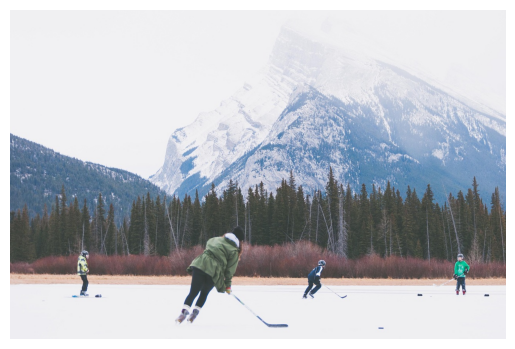

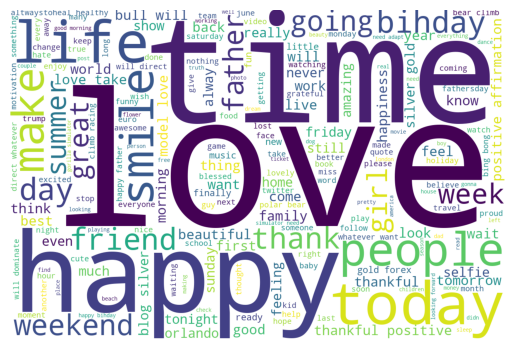

In [26]:
# 인터넷에서 이미지를 읽어서 화면에 출력
#Mask = np.array(Image.open(requests.get('http://clipart-library.com/image_gallery2/Twitter-PNG-Image.png', stream=True).raw))
Mask = np.array(Image.open(requests.get('https://cdn.pixabay.com/photo/2017/08/07/20/07/hockey-2607311_1280.jpg', stream=True).raw))
plt.imshow(Mask)
plt.axis('off')  # 축 숨기기
plt.show()

# Mask의 이미지를 나중에 WordCloud에서 사용할 것입니다.
image_colors = ImageColorGenerator(Mask)

# WordCloud 객체를 생성한다
# WordCloud의 배경은 흰색으로 설정하고 mask는 앞에서 저장한 Mask 변수를 지정한다
# 크기(width, height)는 적절하게 설정한다
# 앞에서 저장한 all_words_positive를 이용해서 WordCloud를 생성하고 그 WordCloud를 화면에 출력한다
# (옵션) WordCloud.recolor() 라는 함수를 이용해서 WordCloud의 색을 변경해 본다

wc = WordCloud(background_color='white', height=1500, width=4000, mask=Mask).generate(all_words_positive)

plt.imshow(wc)
plt.axis('off')
plt.show()


wc.recolor(color_func=image_colors) recolor 메서드는 워드 클라우드의 텍스트 색상을 다시 칠하는 데 사용됩니다. color_func=image_colors는 ImageColorGenerator 객체를 color_func로 사용하여, 마스크 이미지의 색상 정보를 기반으로 워드 클라우드의 텍스트 색상을 다시 칠합니다. image_colors는 이전에 ImageColorGenerator(Mask)로 설정된 객체입니다. 이는 마스크 이미지의 색상 패턴을 사용하여 텍스트를 다시 칠하는 기능을 제공합니다.

Hamming 보간은 두 점 사이의 값을 계산할 때, 주변 픽셀의 가중치를 결정하는 데 사용되는 보간 기법 중 하나입니다.

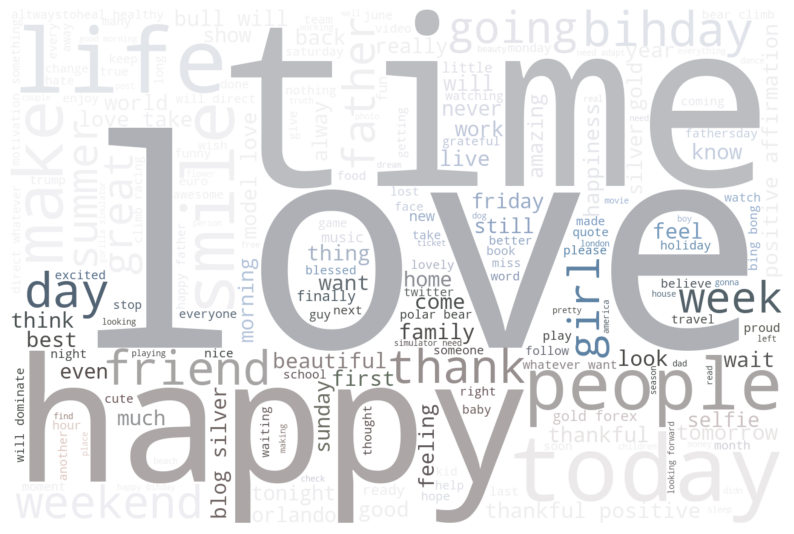

In [27]:
# 앞에서 출력한 WordCloud를 이전에 저장했던 recolor() 메서드와 image_colors라는 색을 이용해서 다시 그려보세요.
plt.figure(figsize=(10,20))

plt.imshow(wc.recolor(color_func=image_colors), interpolation='hamming')
plt.axis('off')
plt.show()


#### Exercise: 부정적인 감정을 위한 Wordcloud를 표시하는 유사한 코드를 작성하세요.

In [29]:
# merge[‘label’]열의 값이 1인 행에서 [‘Clean_Tweets’]의 텍스트를 모두 공백으로 연결한다 
# 연결한 텍스트를 all_words_negative 라는 변수에 저장한다
# your code here 
all_words_negative = ' '.join(text for text in merge[merge['label']==1]['Clean_Tweets'])

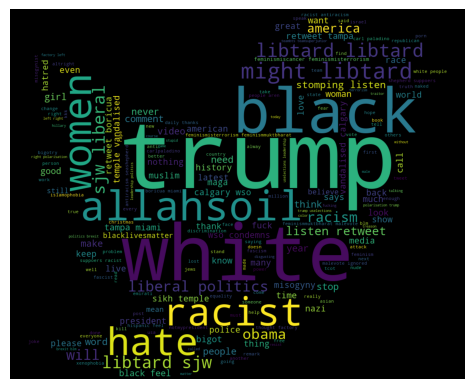

In [30]:
# WordCloud 객체를 생성한다
# WordCloud의 배경은 검은색으로 설정하고 mask는 앞에서 저장한 Mask 변수를 지정한다
# 크기(width, height)는 적절하게 설정한다
# 앞에서 저장한 all_words_negative를 이용해서 WordCloud를 생성합니다.
# your code here 
Mask = np.array(Image.open(requests.get('http://clipart-library.com/image_gallery2/Twitter-PNG-Image.png', stream=True).raw))
#Mask = np.array(Image.open(requests.get('https://cdn.pixabay.com/photo/2017/08/07/20/07/hockey-2607311_1280.jpg', stream=True).raw))

# Mask의 이미지를 나중에 WordCloud에서 사용할 것입니다.
image_colors = ImageColorGenerator(Mask)

# WordCloud 객체를 생성한다
# WordCloud의 배경은 흰색으로 설정하고 mask는 앞에서 저장한 Mask 변수를 지정한다
# 크기(width, height)는 적절하게 설정한다
# 앞에서 저장한 all_words_positive를 이용해서 WordCloud를 생성하고 그 WordCloud를 화면에 출력한다
# (옵션) WordCloud.recolor() 라는 함수를 이용해서 WordCloud의 색을 변경해 본다

wc = WordCloud(background_color='black', height=1500, width=4000, mask=Mask).generate(all_words_negative)

plt.imshow(wc)
plt.axis('off')
plt.show()


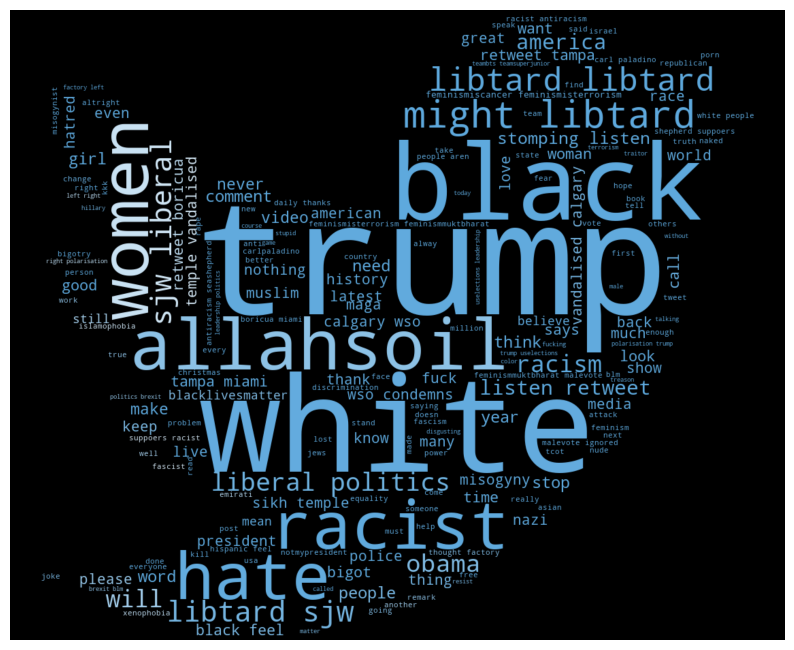

In [31]:
# 앞에서 만든 WordCloud를 화면에 recolor() 메서드와 image_colors라는 색을 이용해서 그려보세요.
# your code here
plt.figure(figsize=(10,20))

plt.imshow(wc.recolor(color_func=image_colors), interpolation='hamming')
plt.axis('off')
plt.show()

findall() 함수는 주어진 텍스트에서 특정 패턴과 일치하는 모든 부분 문자열을 찾아 리스트로 반환합니다.
패턴에 캡처 그룹(())이 포함되어 있으면, 해당 그룹에 일치하는 부분만 반환하며, 캡처 그룹이 없을 경우 전체 패턴과 일치하는 문자열을 반환합니다.

따라서 # 다음의 문자들이 ht에 저장됩니다. 즉 #은 빠지게 됩니다.

In [32]:
import re

text = "This is a #test and #example"

# ()가 있는 정규식
test0 = re.findall(r'#(\w+)', text)
print('()가 있으면 ()내부만 가져온다 :', test0)

# ()가 없는 정규식 
test0 = re.findall(r'#\w+', text)
print('()가 없으면 전체 표현을 가져온다 :', test0)

test0 = re.findall(r'#(\w)+', text)
print('()가 있으면 ()내부만 가져온다 :', test0)

()가 있으면 ()내부만 가져온다 : ['test', 'example']
()가 없으면 전체 표현을 가져온다 : ['#test', '#example']
()가 있으면 ()내부만 가져온다 : ['t', 'e']


In [33]:
# 문자열에서 #태그가 있는 문자열을 찾아서 그 문자열에서 #를 제거한 문자열을 리스트에 저장해서 
# 리턴하는 Hashtags_Extract()라는 함수를 만듭니다.
# your code here 
def Hashtags_Extract(words) :
    hashtags = []
    for word in words :
        ht = re.findall(r'#(\w+)', word)
        hashtags.append(ht)

    return hashtags
    
result = Hashtags_Extract(["#aa bb #cc dd"])
result    # [['aa', 'cc']]

[['aa', 'cc']]

In [34]:
ht_positive = Hashtags_Extract(merge[merge['label']==0]['Clean_Tweets'])

ht_positive[:5]  # 2차원 리스트

[['run'], ['lyft', 'disapointed', 'getthanked'], [], ['model'], ['motivation']]

In [37]:
print(sum([1,2,3]))
sum([1, 2, 3], start=10)    # 10+1+2+3 = 16

6


16

In [38]:
a = ['aa', 'bb'] + ['dd']
a

['aa', 'bb', 'dd']

sum() 함수를 이용해서 2차원 리스트를 1차원 리스트로 변경할 수 있습니다. 

In [41]:
# ht_positive 라는 2차원 리스트를 단어들을 ht_positive_unnest라는 1차원 리스트에 저장한다
# ht_positive_unnest는 [‘run’, ‘lyft’, ‘getthanked’..] 처럼 1차원 리스트 형식이 되도록 한다
# your code hereword
ht_positive_unnest = sum(ht_positive, start=[])
ht_positive_unnest[:5]

['run', 'lyft', 'disapointed', 'getthanked', 'model']

리스트 컴프리헨션으로도 구할 수 있다. 

In [42]:
# your code here 
ht_positive_unnest = [word for sublist in ht_positive for word in sublist]
ht_positive_unnest[:5]

['run', 'lyft', 'disapointed', 'getthanked', 'model']

nltk.FreqDist는 주어진 시퀀스의 각 요소의 빈도 수를 계산하는 클래스입니다. 이를 사용하면 단어 빈도를 쉽게 계산할 수 있습니다. 

In [45]:
# 각 단어별 빈도수를 저장한 Dictionary를 생성한다

word_freq_positive = nltk.FreqDist(ht_positive_unnest)
word_freq_positive

FreqDist({'love': 1596, 'positive': 880, 'smile': 581, 'healthy': 576, 'thankful': 496, 'fun': 463, 'life': 431, 'summer': 395, 'model': 365, 'cute': 365, ...})

word_freq_positive 딕션너리를 df_positive라는 DataFrame에 저장하세요.
컬럼명은 'Hashtags', 'Count' 입니다. 

In [47]:
# your code here
df_positive = pd.DataFrame({'Hashtags': list(word_freq_positive.keys()), 'Count': list(word_freq_positive.values())}) 

df_positive.head(10)

,Hashtags,Count
0,run,34
1,lyft,2
2,disapointed,1
3,getthanked,2
4,model,365
5,motivation,168
6,allshowandnogo,1
7,school,27
8,exams,6
9,hate,25


nlargest(): 단어의 빈도 순으로 상위 n개의 단어를 선택할 수 있습니다.

sns.despine() 이 라인은 그래프의 테두리를 제거하여 깔끔한 시각적 효과를 제공합니다. 구체적으로, 상단과 오른쪽 테두리를 제거합니다.

          Hashtags  Count
32            love   1596
39        positive    880
206          smile    581
158        healthy    576
38        thankful    496
177            fun    463
347           life    431
217         summer    395
4            model    365
359           cute    365
92     affirmation    363
20            blog    346
463     fathersday    341
22            gold    301
21          silver    300
157  altwaystoheal    295
406      beautiful    291
100         bihday    283
385         family    283
108            day    276


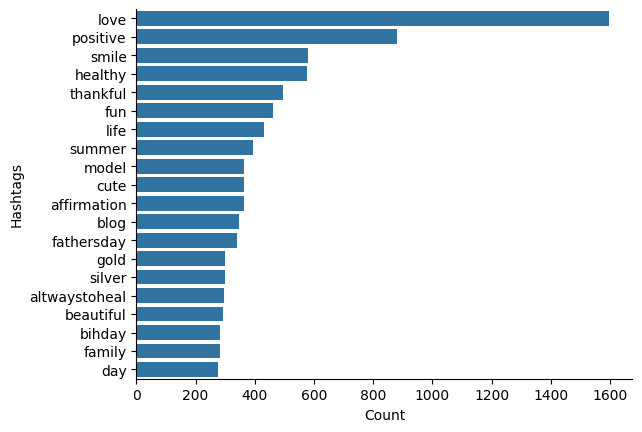

In [48]:
# 빈도수를 기준으로 상위 20개의 단어와 빈도수로 막대그래프를 그립니다.

df_positive_plot = df_positive.nlargest(20, columns='Count')
print(df_positive_plot)
sns.barplot(data=df_positive_plot, y='Hashtags', x='Count')
sns.despine()

#### Exercise: 유사한 코드로 부정적인 해시태그를 추출한 후, 이를 펼쳐서 처리하세요.

In [46]:
ht_negative = Hashtags_Extract(merge[merge['label']==1]['Clean_Tweets'])

ht_negative[:5]

[['cnn', 'michigan', 'tcot'],
 ['australia',
  'opkillingbay',
  'seashepherd',
  'helpcovedolphins',
  'thecove',
  'helpcovedolphins'],
 [],
 [],
 ['neverump', 'xenophobia']]

In [47]:
# ht_negative 라는 2차원 리스트를 단어들을 ht_negative_unnest라는 1차원 리스트에 저장한다
# ht_negative_unnest는 [‘cnn’, ‘michigan’, ‘tcot’..] 처럼 1차원 리스트 형식이 되도록 한다
# your code here


['cnn', 'michigan', 'tcot', 'australia', 'opkillingbay']

In [48]:
# 각 단어별 빈도수를 저장한 Dictionary를 생성한다
# your code here


FreqDist({'trump': 136, 'politics': 95, 'allahsoil': 92, 'libtard': 76, 'liberal': 75, 'sjw': 74, 'retweet': 63, 'miami': 46, 'black': 44, 'hate': 33, ...})

word_freq_negative 딕션너리를 df_negative라는 DataFrame에 저장하세요.
컬럼명은 'Hashtags', 'Count' 입니다.

In [ ]:
# your code here


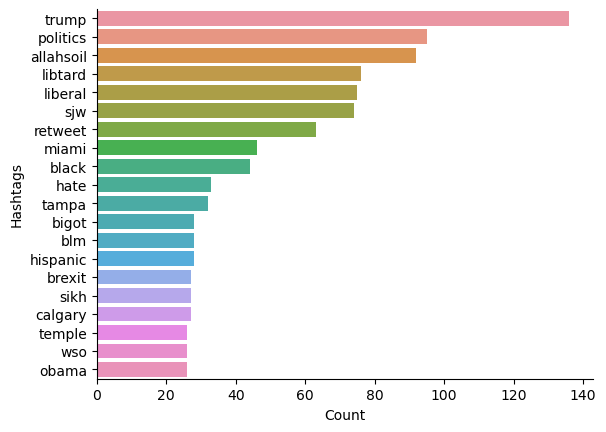

In [50]:
# 빈도수를 기준으로 상위 20개의 단어와 빈도수로 막대그래프를 그립니다.
# your code here 


CountVectorizer 소개 : CountVectorizer는 텍스트 데이터를 단어의 빈도수(단어의 출현 횟수)로 변환합니다. 이를 통해 머신 러닝 알고리즘이 텍스트 데이터를 처리할 수 있게 됩니다.

In [52]:
# CountVectorizer 객체를 선언하는데 단어가 전체 문서의 90% 이상 등장하면 무시하도록 하고 최소 2개이상의 문서에 등장해야하며 
# 가장 빈도수가 높은 상위 1000개 단어만을 벡터화 하도록 하고(1000개의 차원), Stop_words는 english로 설정하도록 한다
# 이 객체를 이용해 merge[‘Clean_Tweets’]열을 Bag-of-words 행렬로 만든다
# 그 행렬로 DataFrame을 만든다 
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_df=0.90, min_df=2, max_features=1000, stop_words='english')
bow = bow_vectorizer.fit_transform(merge['Clean_Tweets'])
print(bow)

df_bow = pd.DataFrame(bow.todense())
df_bow

  (0, 269)	1
  (0, 453)	1
  (1, 866)	1
  (1, 107)	1
  (2, 55)	1
  (3, 557)	1
  (3, 516)	1
  (3, 878)	1
  (4, 568)	1
  (5, 416)	1
  (5, 849)	1
  (5, 479)	1
  (6, 884)	1
  (7, 736)	2
  (7, 991)	2
  (7, 870)	1
  (7, 381)	1
  (7, 425)	1
  (7, 333)	1
  (8, 516)	1
  (8, 108)	1
  (9, 959)	1
  (10, 672)	1
  (10, 64)	1
  (10, 765)	1
  :	:
  (49154, 656)	1
  (49154, 481)	1
  (49154, 474)	1
  (49154, 63)	1
  (49155, 491)	1
  (49155, 276)	1
  (49155, 954)	1
  (49156, 882)	1
  (49156, 491)	1
  (49156, 976)	1
  (49156, 401)	1
  (49156, 977)	1
  (49156, 917)	1
  (49157, 378)	1
  (49157, 978)	2
  (49157, 147)	1
  (49157, 714)	1
  (49157, 551)	2
  (49157, 475)	1
  (49157, 166)	1
  (49157, 198)	1
  (49157, 613)	1
  (49158, 310)	1
  (49158, 785)	1
  (49158, 338)	1


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49154,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49156,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49157,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
# 슬라이싱 기법으로 앞에서 저장한 bag-of-words matrix의 상위 31962개의 데이터를 학습을 위한 X 데이터인 train_bow로 설정한다
# your code here


matrix([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

## Model Building and Evaluation (AI Project Cycle - Step 3 & 4)

### Using Bag of Words(BOW) Features

In [57]:
# train_bow 데이터의 70%를 Train 데이터로 30%를 Test 데이터로 총 31962개의 데이터를 분할한다
# 4가지 변수명은 x_train_bow, x_test_bow, y_train_bow, y_test_bow로 설정
# your code here


solver 매개변수는 LogisticRegression 클래스에서 사용되는 최적화 알고리즘을 지정하는 데 사용됩니다. 로지스틱 회귀 모델을 학습할 때, 손실 함수를 최소화하기 위해 최적화 알고리즘을 사용합니다. solver 매개변수는 어떤 최적화 알고리즘을 사용할지를 결정합니다.

solver 매개변수의 옵션

LogisticRegression에서 사용할 수 있는 solver 옵션은 다음과 같습니다:

newton-cg:

Newton-Conjugate Gradient 알고리즘입니다.

L2 정규화된 로지스틱 회귀에 적합합니다.

lbfgs:

Broyden-Fletcher-Goldfarb-Shanno (BFGS) 알고리즘의 확장판인 Limited-memory BFGS 알고리즘입니다.

L2 정규화된 로지스틱 회귀에 적합합니다.

기본값으로 자주 사용됩니다.

liblinear:

작은 데이터셋에 적합한 알고리즘입니다.

L1 및 L2 정규화 모두 지원합니다.

이진 분류 및 작은 데이터셋에 적합합니다.

sag:

Stochastic Average Gradient Descent 알고리즘입니다.

대규모 데이터셋에 적합합니다.

L2 정규화된 로지스틱 회귀에 적합합니다.

saga:

sag 알고리즘의 변형으로, L1, L2 및 Elastic Net 정규화를 지원합니다.

대규모 데이터셋에 적합합니다.

saga는 다중 클래스 문제와 희소 데이터셋에 적합합니다.

In [ ]:
#Modeling
#LogisticRegression 객체를 생성하고 앞에서 만든 Train 데이터로 학습한다
#LogisticRegression의 solver 매개변수는 newton-cg, lbfgs, liblinear, sag, saga 등이 있는데 적절한 매개변수를 선택한다

from sklearn.linear_model import LogisticRegression
# your code here 


In [63]:
# 학습한 모델로 Test 데이터를 이용해서 추론을 진행한다
# your code here 


array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [64]:
#Evaluation
# accuracy_score()와 classification_report()를 이용해서 모델의 성능을 확인한다

from sklearn.metrics import accuracy_score, classification_report
# your code here 


Train Accuracy Score for Logistic Regression using bow method: 0.9485869225153822

Classification Report : 

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      9293
           1       0.35      0.81      0.49       296

    accuracy                           0.95      9589
   macro avg       0.67      0.88      0.73      9589
weighted avg       0.97      0.95      0.96      9589



[[8855   55]
 [ 438  241]]


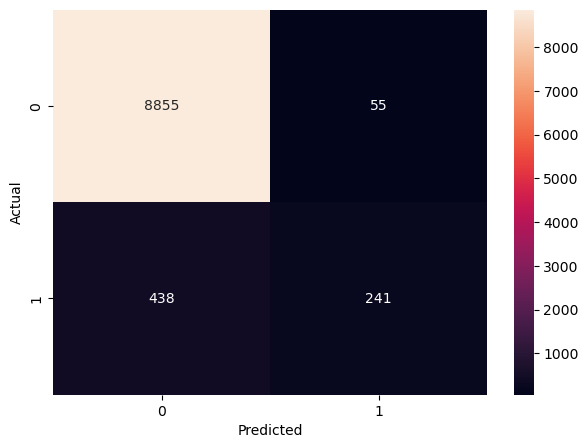

In [65]:
# confusion_matrix 데이터를 구하고, 그 내용을 sns.heatmap()으로 화면에 출력한다

from sklearn.metrics import confusion_matrix
# your code here 


### Using TF- IDF Features

TF-IDF 소개: TF-IDF(Term Frequency-Inverse Document Frequency)는 텍스트 데이터를 단어의 중요도로 변환하는 방법입니다. 단순한 빈도수 기반 접근법인 CountVectorizer와 달리, TF-IDF는 특정 단어가 문서 내에서 얼마나 중요한지를 반영하여 가중치를 부여합니다. 이를 통해 머신 러닝 알고리즘이 텍스트 데이터를 보다 효과적으로 처리할 수 있습니다.

In [66]:
# TfidfVectorizer 객체를 선언하는데 단어가 전체 문서의 90% 이상 등장하면 무시하도록 하고 최소 2개이상의 문서에 등장해야하며 
# 가장 빈도수가 높은 상위 1000개 단어만을 벡터화 하도록 하고(1000개의 차원)
# Stop_words는 english로 설정하도록 한다
# 이 객체를 이용해 merge[‘Clean_Tweets’]열을 TF-IDF 행렬로 만든다
# 만든 행렬로 DataFrame을 만든다 

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(merge['Clean_Tweets'])
df_tfidf = pd.DataFrame(tfidf_matrix.todense())
df_tfidf

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# 슬라이싱 기법으로 앞에서 저장한 TFIDF matrix의 상위 31962개의 데이터를 학습을 위한 X 데이터인 train_tfidf_matrix로 설정한다
# your code here


matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]])

In [40]:
# train 데이터는 70%, test 데이터는 30%로 31962개의 데이터를 분할한다
# your code here


In [41]:
#Building Logistic Regression Model
#LogisticRegression 객체를 생성하고 앞에서 만든 Training 데이터로 학습한다
#LogisticRegression의 solver 매개변수는 newton-cg, lbfgs, liblinear, sag, saga 등이 있는데 적절한 매개변수를 선택한다
# your code here 


LogisticRegression(random_state=0)

In [42]:
# 학습한 모델로 Test 데이터를 이용해서 추론을 진행한다
# your code here 


array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [43]:
#Evaluation
# accuracy_score()와 classification_report()를 이용해서 모델의 성능을 확인한다
# your code here 



Train Accuracy Score for Logistic Regression using TFIDF method: 0.9509855042235895

Classification Report : 

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      9311
           1       0.35      0.82      0.49       278

    accuracy                           0.95      9589
   macro avg       0.67      0.89      0.73      9589
weighted avg       0.98      0.95      0.96      9589



[[8891   50]
 [ 420  228]]


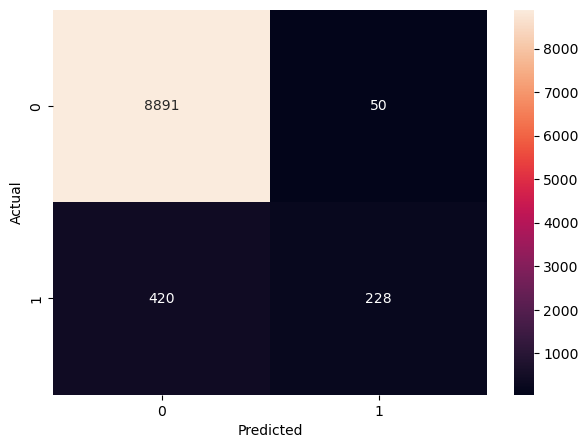

In [44]:
# confusion_matrix 데이터를 구하고, 그 내용을 sns.heatmap()으로 화면에 출력한다
# your code here 


### 이제 Bag of Words 모델을 기반으로 로지스틱 회귀를 사용하여 보이지 않는 테스트 데이터의 레이블을 예측해 보겠습니다.

이전에 만들었던 bag-of-words 벡터와 TFIDF 벡터 중 31962부터 끝까지의 데이터는 test.csv 데이터입니다. 참고로 test.csv에는 ‘label’이라는 Target 컬럼은 없습니다.

Bag-of-words, TFIDF, 2개의 데이터에 대해서 test.csv 데이터에 해당되는 데이터를 추출해서 추론을 진행합니다. 
먼저 Bag-of-words로 학습한 LogisticRegression 모델로 test 테스트를 추론하고 그 결과를 파일에 저장합니다. (id, tweet, label 의 DataFrame을 파일에 저장) 

In [ ]:
# Bag-of-words 데이터의 31962 부터 끝까지를 적당한 이름으로 테스트 데이터로 저장합니다.
# 앞에서 만든 모델로 추론 한 후 추론 결과를 맨 앞에서 만들었던 test 라는 DataFrame에 'label'이라는 컬럼에 저장합니다.
# test DataFrame 중 id, label 컬럼을 csv 파일에 저장 
# your code here


In [74]:
# 저장한 파일을 다시 읽어서 DataFrame을 출력합니다.
# your code here


,id,label
0,31963,0
1,31964,0
2,31965,0
3,31966,0
4,31967,0
...,...,...
17192,49155,1
17193,49156,0
17194,49157,0
17195,49158,0


### Exercise : TF-IDF 특성을 기반으로 로지스틱 회귀를 사용하여 테스트 데이터의 라벨을 예측하세요

In [75]:
# TFIDF 데이터의 31962 부터 끝까지를 적당한 이름으로 테스트 데이터로 저장합니다.
# 앞에서 만든 모델로 추론 한 후 추론 결과를 맨 앞에서 만들었던 test 라는 DataFrame에 'label'이라는 컬럼에 저장합니다.
# test DataFrame 중 id, label 컬럼을 csv 파일에 저장 
# your code here 


In [76]:
# 저장한 파일을 다시 읽어서 DataFrame을 출력합니다.
# your code here


,id,label
0,31963,0
1,31964,0
2,31965,0
3,31966,0
4,31967,0
...,...,...
17192,49155,1
17193,49156,0
17194,49157,0
17195,49158,0


In [8]:
# 예제 데이터로 사용할 문장들
sentences = [
    "Having a wonderful day with friends and family enjoying the sunshine and good vibes",
    "Had a terrible day due to racism encountered on the subway.",
    "Feeling grateful for the support of my friends during tough times.",
    "Excited about the new project at work, looking forward to the challenge.",
    "Feeling stressed out and overwhelmed with all the deadlines this week."
]

# 문장들을 포함하는 DataFrame 생성한 후 이전에 진행했던 텍스트 전처리를 진행한 후 정제된 텍스트를 DataFrame에 저장합니다.
# your code here
sample = pd.DataFrame(sentences, columns=['Sample_Tweets'])
sample['Sample_Tweets'] = sample['Sample_Tweets'].apply(clean_text)
sample['Sample_Tweets'] = sample['Sample_Tweets'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
sample

,Sample_Tweets
0,having wonderful with friends family enjoying ...
1,terrible racism encountered subway
2,feeling grateful support friends during tough ...
3,excited about project work looking forward cha...
4,feeling stressed overwhelmed with deadlines th...


In [ ]:
# 이전에 학습된 CountVectorizer 모델(bow_vectorizer)을 사용하여 bag-of-words 형식의 데이터로 변경합니다.
# your code here


In [78]:
# 예전에 학습된 bag-of-words 로지스틱 회귀 모델을 사용하여 예측하고 추론 결과를 출력합니다.
# your code here


Sentence: Having a wonderful day with friends and family enjoying the sunshine and good vibes => Prediction: 0
Sentence: Had a terrible day due to racism encountered on the subway. => Prediction: 1
Sentence: Feeling grateful for the support of my friends during tough times. => Prediction: 0
Sentence: Excited about the new project at work, looking forward to the challenge. => Prediction: 0
Sentence: Feeling stressed out and overwhelmed with all the deadlines this week. => Prediction: 0


In [ ]:
# 이전에 학습된 TF-IDF 모델을 사용하여 TF-IDF 형식의 데이터로 변경합니다.
# your code here


In [ ]:
# 예전에 학습된 TF-IDF 로지스틱 회귀 모델을 사용하여 예측하고 추론 결과를 출력합니다.
# your code here


## Observations:

- 이 노트북은 로지스틱 회귀를 사용하여 소셜 미디어 게시물을 긍정적(비혐오) 또는 부정적(혐오)으로 분류하는 NLP 기반 AI/ML 모델 구축 과정을 보여줍니다.
- 모델은 단어 가방(bag-of-words)과 tf-idf 특성을 사용하여 훈련되었습니다.
- 모델의 정확도는 혼동 행렬, 분류 보고서 및 정확도 점수를 사용하여 평가되었습니다.
- Scikit-learn-intelex (sklearnex)의 사용도 특수 소프트웨어 최적화를 통해 Scikit-learn 라이브러리를 가속화하는 방법을 시연했습니다.

## References: 

- https://anaconda.cloud/greener-ml-intel
- https://towardsdatascience.com/social-media-sentiment-analysis-part-ii-bcacca5aaa39\
- https://towardsdatascience.com/social-media-sentiment-analysis-49b395771197